In [240]:
from datasets import Dataset, DatasetDict
from huggingface_hub import login
import json
import pandas as pd
from datasets import Dataset, Features, Value, Sequence
import pandas as pd

In [261]:
data_config = "diamond"

In [262]:
df_linear = pd.read_json("/Users/abhigya.verma/Downloads/v2_updated_think_trace/" + data_config + ".json")
df_linear.head()

,id,conversation,expected_response,tools,thoughts,metadata
0,6d9a67460d17fd5a6ce02f7fbbb2ada6,[{'content': 'You are an intelligent system fo...,{'content': 'The user supplied the current gri...,"[{'type': 'function', 'function': {'name': 'sh...","The user supplied the current grid supply, dem...",{'source_id': 'enterprise_tools_two_sequential...
1,270b69b7b87eccfd820ed94a3c5de994,[{'content': 'You are highly skilled at using ...,{'content': 'The compliance check returned (Tr...,"[{'type': 'function', 'function': {'name': 'Us...","The compliance check returned (True, []), so t...",{'source_id': 'enterprise_tools_two_sequential...
2,4cb381957e3119001db163e11006f14b,[{'content': 'You are an expert in composing f...,{'content': 'The user supplied vehicle ID VH-9...,"[{'type': 'function', 'function': {'name': 'sh...","The user supplied vehicle ID VH-9876, timestam...",{'source_id': 'enterprise_tools_multiple_seque...
3,e1f9c1589501e4945a0da95bbec8d53a,[{'content': 'You are responsible for interpre...,{'content': 'The previous validation returned ...,"[{'type': 'function', 'function': {'name': 'va...",The previous validation returned a boolean ind...,{'source_id': 'enterprise_tools_multiple_seque...
4,f357b91da9de3b8cc6e66fad71e05442,[{'content': 'You are a tool-using assistant. ...,{'content': 'The compliance validation returne...,"[{'type': 'function', 'function': {'name': 'va...",The compliance validation returned that the sh...,{'source_id': 'enterprise_tools_multiple_seque...


In [263]:
df_linear.head()

,id,conversation,expected_response,tools,thoughts,metadata
0,6d9a67460d17fd5a6ce02f7fbbb2ada6,[{'content': 'You are an intelligent system fo...,{'content': 'The user supplied the current gri...,"[{'type': 'function', 'function': {'name': 'sh...","The user supplied the current grid supply, dem...",{'source_id': 'enterprise_tools_two_sequential...
1,270b69b7b87eccfd820ed94a3c5de994,[{'content': 'You are highly skilled at using ...,{'content': 'The compliance check returned (Tr...,"[{'type': 'function', 'function': {'name': 'Us...","The compliance check returned (True, []), so t...",{'source_id': 'enterprise_tools_two_sequential...
2,4cb381957e3119001db163e11006f14b,[{'content': 'You are an expert in composing f...,{'content': 'The user supplied vehicle ID VH-9...,"[{'type': 'function', 'function': {'name': 'sh...","The user supplied vehicle ID VH-9876, timestam...",{'source_id': 'enterprise_tools_multiple_seque...
3,e1f9c1589501e4945a0da95bbec8d53a,[{'content': 'You are responsible for interpre...,{'content': 'The previous validation returned ...,"[{'type': 'function', 'function': {'name': 'va...",The previous validation returned a boolean ind...,{'source_id': 'enterprise_tools_multiple_seque...
4,f357b91da9de3b8cc6e66fad71e05442,[{'content': 'You are a tool-using assistant. ...,{'content': 'The compliance validation returne...,"[{'type': 'function', 'function': {'name': 'va...",The compliance validation returned that the sh...,{'source_id': 'enterprise_tools_multiple_seque...


In [264]:
import pandas as pd
import json

def extract_conversation_data(conversation_list):
    # Initialize variables to collect data
    system_prompt = None
    available_tools = None
    user_message = None
    expected_responses = []

    for turn in conversation_list:
        role = turn.get('role')
        content = turn.get('content')

        if role == 'system':
            # Extract system prompt
            system_prompt = content
            # Extract tools from the 'tools' field
            available_tools = turn.get('tools')

        elif role == 'user':
            # This is the user query
            user_message = content

        elif role == 'assistant':
            # Collect assistant responses (including reasoning and tool calls)
            expected_response = {
                'role': 'assistant',
                'tool_calls': turn.get('tool_calls'),
                'reasoning_content': turn.get('reasoning_content'),
                'content': turn.get('content')
            }
            expected_responses.append(expected_response)

        elif role == 'tool':
            # Collect tool results
            expected_response = {
                'role': 'tool',
                'content': turn.get('content'),
                'tool_call_id': turn.get('tool_call_id'),
                'name': turn.get('name')
            }
            expected_responses.append(expected_response)

    # Return as dict for single conversation
    return {
        'system_prompt': system_prompt,
        'available_tools': available_tools,
        'user_message': user_message,
        'expected_responses': expected_responses
    }


# Simple apply and concat
df_extracted = pd.DataFrame(df_linear['conversation'].apply(extract_conversation_data).tolist())
df_structured = pd.concat([df_linear.drop('conversation', axis=1), df_extracted], axis=1)

In [265]:
df_structured.head()

,id,expected_response,tools,thoughts,metadata,system_prompt,available_tools,user_message,expected_responses
0,6d9a67460d17fd5a6ce02f7fbbb2ada6,{'content': 'The user supplied the current gri...,"[{'type': 'function', 'function': {'name': 'sh...","The user supplied the current grid supply, dem...",{'source_id': 'enterprise_tools_two_sequential...,You are an intelligent system for composing fu...,"[{""type"": ""function"", ""function"": {""name"": ""sh...",Given that the grid is currently supplying 850...,"[{'role': 'assistant', 'tool_calls': '[{""funct..."
1,270b69b7b87eccfd820ed94a3c5de994,{'content': 'The compliance check returned (Tr...,"[{'type': 'function', 'function': {'name': 'Us...","The compliance check returned (True, []), so t...",{'source_id': 'enterprise_tools_two_sequential...,You are highly skilled at using tools to accom...,"[{""type"": ""function"", ""function"": {""name"": ""Us...",I’m configuring a telemedicine session that sh...,"[{'role': 'assistant', 'tool_calls': '[{""funct..."
2,4cb381957e3119001db163e11006f14b,{'content': 'The user supplied vehicle ID VH-9...,"[{'type': 'function', 'function': {'name': 'sh...","The user supplied vehicle ID VH-9876, timestam...",{'source_id': 'enterprise_tools_multiple_seque...,You are an expert in composing functions. Give...,"[{""type"": ""function"", ""function"": {""name"": ""sh...",I have a telemetry record from vehicle VH‑9876...,"[{'role': 'assistant', 'tool_calls': '[{""funct..."
3,e1f9c1589501e4945a0da95bbec8d53a,{'content': 'The previous validation returned ...,"[{'type': 'function', 'function': {'name': 'va...",The previous validation returned a boolean ind...,{'source_id': 'enterprise_tools_multiple_seque...,You are responsible for interpreting natural l...,"[{""type"": ""function"", ""function"": {""name"": ""va...",I’m setting up MFA for our corporate VPN and w...,"[{'role': 'assistant', 'tool_calls': '[{""funct..."
4,f357b91da9de3b8cc6e66fad71e05442,{'content': 'The compliance validation returne...,"[{'type': 'function', 'function': {'name': 'va...",The compliance validation returned that the sh...,{'source_id': 'enterprise_tools_multiple_seque...,You are a tool-using assistant. For every quer...,"[{""type"": ""function"", ""function"": {""name"": ""va...",I’m preparing to ship a batch of electronics (...,"[{'role': 'assistant', 'tool_calls': '[{""funct..."


In [266]:
df_structured["dag_type"] = data_config

In [267]:
df_clean = pd.concat([df_clean, df_structured])

In [268]:
# df_clean = df_structured

In [269]:
df_clean.shape

(3808, 10)

In [270]:
df_clean.head()

,id,tools,thoughts,expected_response,metadata,system_prompt,available_tools,user_message,expected_responses,dag_type
0,feac10a874c2495aa6881d541f50805c,"[{'type': 'function', 'function': {'name': 'va...",The validation step returned is_covered = True...,{'content': 'The validation step returned is_c...,{'source_id': 'enterprise_tools_multiple_seque...,You are responsible for interpreting natural l...,"[{""type"": ""function"", ""function"": {""name"": ""va...",Can you verify whether my insurance claim ID C...,"[{'role': 'assistant', 'tool_calls': '[{""funct...",linear
1,06c4096f638fb0d434178b0e81635155,"[{'type': 'function', 'function': {'name': 'Us...",The compliance check returned is_compliant = T...,{'content': 'The compliance check returned is_...,{'source_id': 'enterprise_tools_two_sequential...,You are a tool-using assistant. For every quer...,"[{""type"": ""function"", ""function"": {""name"": ""Us...",I’m setting up a telemedicine group session th...,"[{'role': 'assistant', 'tool_calls': '[{""funct...",linear
2,934cb9030a08668b6101c331419dabc3,"[{'type': 'function', 'function': {'name': 'sh...",The preprocessing step produced a cleaned vers...,{'content': 'The preprocessing step produced a...,{'source_id': 'enterprise_tools_multiple_seque...,You are an expert in identifying which functio...,"[{""type"": ""function"", ""function"": {""name"": ""sh...",Please analyze the sentiment of this exact cus...,"[{'role': 'assistant', 'tool_calls': '[{""funct...",linear
3,873ffcd47d5324d2bf5b92254c04c704,"[{'type': 'function', 'function': {'name': 'di...",The previous analysis returned a bandwidth usa...,{'content': 'The previous analysis returned a ...,{'source_id': 'enterprise_tools_two_sequential...,You are highly skilled at using tools to accom...,"[{""type"": ""function"", ""function"": {""name"": ""di...",My network interface is configured for 1000 Mb...,"[{'role': 'assistant', 'tool_calls': '[{""funct...",linear
4,e9c4fefbd1d0283a6dab79b96570d6d6,"[{'type': 'function', 'function': {'name': 'Us...",The analysis function returned an average band...,{'content': 'The analysis function returned an...,{'source_id': 'enterprise_tools_two_sequential...,You are highly skilled at using tools to accom...,"[{""type"": ""function"", ""function"": {""name"": ""Us...",Given that my server’s bandwidth usage over th...,"[{'role': 'assistant', 'tool_calls': '[{""funct...",linear


In [271]:
df_clean["dag_type"].value_counts()

dag_type
fan_in                 1049
optional_enrichment     823
linear                  812
diamond                 501
fan_out                 399
loop_like               224
Name: count, dtype: int64

In [276]:
import pandas as pd

df_sampled = (
    df_clean
    .groupby("dag_type", group_keys=False)
    .apply(lambda x: x.sample(n=min(100, len(x)), random_state=42))
    .reset_index(drop=True)
)

/var/folders/rd/3g0jzl8j5sdgj7h_3bf7hh_40000gn/T/ipykernel_87826/2136133823.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(100, len(x)), random_state=42))


In [277]:
df_sampled["dag_type"].value_counts()

dag_type
diamond                100
fan_in                 100
fan_out                100
linear                 100
loop_like              100
optional_enrichment    100
Name: count, dtype: int64

In [278]:
df_clean = df_sampled

In [279]:
def to_json_string(obj):
    # Handle NaN/None values
    if obj is None or (isinstance(obj, float) and np.isnan(obj)):
        return json.dumps(None)

    # If already a string, check if it's valid JSON
    if isinstance(obj, str):
        try:
            json.loads(obj)
            return obj
        except:
            return obj

    # Convert lists, dicts, arrays, or other objects to JSON
    return json.dumps(obj, ensure_ascii=False, default=str)

# Convert all object-type columns to JSON strings
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].apply(to_json_string)

In [280]:
# Create the dataset from the cleaned dataframe
dataset = Dataset.from_pandas(df_clean, preserve_index=False)

In [281]:
record_dict = df_structured.iloc[0].to_dict()

# Pretty print
import json
print(json.dumps(record_dict, indent=2, default=str))

{
  "id": "6d9a67460d17fd5a6ce02f7fbbb2ada6",
  "expected_response": {
    "content": "The user supplied the current grid supply, demand, interval length, historical demand values, and maximum generation capacity. The previous function calls have already computed the predicted demand for the next interval (1012.33 MW) and the generator utilization ratio (0.8505) based on the current supply and max capacity (1000 MW). These results are directly available and satisfy the required inputs for the allocation adjustment function. Therefore, I use the predicted demand, utilization ratio, and the known maximum capacity as arguments to calculate the additional supply needed.",
    "name": null,
    "role": "assistant",
    "tool_call_id": null,
    "tool_calls": "[{\"function\": {\"name\": \"adjust_energy_allocation\", \"arguments\": {\"predicted_demand\": 1012.33, \"utilization_ratio\": 0.8505, \"max_capacity\": 1000}}, \"type\": \"function\", \"id\": \"step4\"}]",
    "tools": null
  },
  "to

In [282]:
dataset.push_to_hub(
    "ServiceNow-AI/BFCL_agentic_judge_bench",
    config_name="mix_sample"
)

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 24.46ba/s]
Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (0 / 1):   9%|▉         |  525kB / 5.83MB,  239kB/s  
Processing Files (0 / 1):  18%|█▊        | 1.05MB / 5.83MB,  328kB/s  
Processing Files (0 / 1):  27%|██▋       | 1.58MB / 5.83MB,  463kB/s  
Processing Files (0 / 1):  45%|████▌     | 2.63MB / 5.83MB,  691kB/s  
Processing Files (0 / 1):  81%|████████  | 4.73MB / 5.83MB, 1.18MB/s  
Processing Files (0 / 1):  99%|█████████▉| 5.78MB / 5.83MB, 1.31MB/s  
Processing Files (1 / 1): 100%|██████████| 5.83MB / 5.83MB, 1.17MB/s  
Processing Files (1 / 1): 100%|██████████| 5.83MB / 5.83MB, 1.08MB/s  
New Data Upload: 100%|██████████| 5.83MB / 5.83MB, 1.08MB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:06<00:00,  6.63s/ shards]


CommitInfo(commit_url='https://huggingface.co/datasets/ServiceNow-AI/BFCL_agentic_judge_bench/commit/3a88e7699b0a40bd24a9a62fd0eb406af7703036', commit_message='Upload dataset', commit_description='', oid='3a88e7699b0a40bd24a9a62fd0eb406af7703036', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/ServiceNow-AI/BFCL_agentic_judge_bench', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ServiceNow-AI/BFCL_agentic_judge_bench'), pr_revision=None, pr_num=None)

# Evaluate Performace

In [100]:
import pandas as pd

In [296]:
df = pd.read_json("/Users/abhigya.verma/git/SyGra/tasks/examples/agentic_bfcl_judge_eval/mix_sample_openaigpt5.json")

In [297]:
df.head()

,user_message,available_tools,expected_responses,generated_tool_calls,judge_response,judge_response_no_gt,programmatic_judge_response,per_metric_comparison,overall_llm_alignment_percentage,per_metric_comparison_no_gt,overall_llm_alignment_percentage_no_gt
0,"My patient ID is 987654321, my full legal name...","[{'type': 'function', 'function': {'name': 've...","[{'role': 'assistant', 'tool_calls': [{'functi...",[{'function': {'name': 'verify_patient_identit...,"{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0},...",{'tool_selection_accuracy': {'programmatic_acc...,100.0,{'tool_selection_accuracy': {'programmatic_acc...,100.0
1,"In the 1,500‑square‑meter Zone B of the airpor...","[{'type': 'function', 'function': {'name': 'ca...","[{'role': 'assistant', 'tool_calls': [{'functi...",[{'function': {'name': 'calculate_passenger_de...,"{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0},...",{'tool_selection_accuracy': {'programmatic_acc...,100.0,{'tool_selection_accuracy': {'programmatic_acc...,100.0
2,None,None,None,None,None,None,None,None,NaN,None,NaN
3,For a three‑segment trip with segment distance...,"[{'type': 'function', 'function': {'name': 'ca...","[{'role': 'assistant', 'tool_calls': [{'functi...",[{'function': {'name': 'calculate_energy_cost_...,"{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0},...",{'tool_selection_accuracy': {'programmatic_acc...,100.0,{'tool_selection_accuracy': {'programmatic_acc...,100.0
4,"My warehouse can hold 1500 units, I currently ...","[{'type': 'function', 'function': {'name': 'ca...","[{'role': 'assistant', 'tool_calls': [{'functi...",[{'function': {'name': 'calculate_reorder_poin...,"{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0, ...","{'tool_selection_accuracy': {'accuracy': 1.0},...",{'tool_selection_accuracy': {'programmatic_acc...,100.0,{'tool_selection_accuracy': {'programmatic_acc...,100.0


In [298]:
df["overall_llm_alignment_percentage"].astype(float).mean()

np.float64(94.58833333333334)

In [299]:
df["overall_llm_alignment_percentage_no_gt"].astype(float).mean()

np.float64(92.05287234042552)

In [305]:
def extract_low_score_samples(df):
    low_score_samples = []

    for idx, row in df.iterrows():
        judge = row.get('programmatic_judge_response', {})
        if isinstance(judge, str):
            judge = json.loads(judge)

        if not judge:
            continue

        scores = {
            'tool_selection': (judge.get('tool_selection_accuracy') or {}).get('accuracy', 1.0),
            'parameter_structure': (judge.get('parameter_structure_accuracy') or {}).get('accuracy', 1.0),
            'sequence': (judge.get('sequence_accuracy') or {}).get('accuracy', 1.0),
            'query_coverage': (judge.get('query_coverage_accuracy') or {}).get('accuracy', 1.0),
        }

        avg_score = sum(scores.values()) / len(scores)

        if any(v < 1.0 for v in scores.values()) or avg_score < 0.8:

            # Extract available tool names
            available_tools = row.get('available_tools', [])
            tool_names = [t.get('function', {}).get('name') for t in available_tools] if available_tools else []

            # Extract generated tool calls
            generated_calls = row.get('generated_tool_calls', [])
            generated_tool_summary = [
                {
                    'name': c.get('function', {}).get('name'),
                    'arguments': c.get('function', {}).get('arguments')
                } for c in generated_calls
            ] if generated_calls else []

            # Extract expected tool calls from expected_responses
            expected_responses = row.get('expected_responses', [])
            expected_tool_summary = []
            for resp in expected_responses:
                if isinstance(resp, dict) and resp.get('role') == 'assistant':
                    for tc in (resp.get('tool_calls') or []):
                        expected_tool_summary.append({
                            'name': tc.get('function', {}).get('name'),
                            'arguments': tc.get('function', {}).get('arguments')
                        })

            low_score_samples.append({
                'index': idx,
                'avg_score': avg_score,
                **scores,
                'user_message': row.get('user_message', ''),
                'available_tools': tool_names,
                'generated_tool_calls': generated_tool_summary,
                'expected_tool_calls': expected_tool_summary,
            })

    result_df = pd.DataFrame(low_score_samples)
    return result_df.sort_values('avg_score') if not result_df.empty else result_df

low_scores_df = extract_low_score_samples(df)
print(f"Samples with wrong/low-scoring tool calls: {len(low_scores_df)}")

# Display with full column content
pd.set_option('display.max_colwidth', None)
low_scores_df[['index', 'avg_score', 'tool_selection', 'parameter_structure',
               'sequence', 'query_coverage', 'user_message',
               'available_tools', 'generated_tool_calls', 'expected_tool_calls']]

Samples with wrong/low-scoring tool calls: 142


,index,avg_score,tool_selection,parameter_structure,sequence,query_coverage,user_message,available_tools,generated_tool_calls,expected_tool_calls
80,400,0.16665,0.3333,0.000,0.0,0.3333,"I have the exact daily sales figures for the past 30 days for my product: 12.0, 15.5, 13.2, 14.8, 16.1, 15.0, 14.3, 13.7, 12.5, 14.2, 15.6, 13.9, 16.4, 14.7, 15.3, 13.1, 14.9, 12.8, 13.4, 15.2, 14.0, 12.3, 13.6, 15.8, 14.5, 13.0, 12.7, 15.1, 14.6, 13.5. The sales show a clear weekly pattern, so use a frequency of 7. I want to achieve a 97 % service level and my supplier’s lead time is 4 days. Based on this data, what safety‑stock quantity should I maintain?","[calculate_moving_average_sales, analyze_seasonality_index, predict_inventory_restock_point, calculate_sales_variance, calculate_safety_stock, estimate_lead_time_demand, calculate_service_level_factor, calculate_safety_stock_2, optimize_reorder_point, forecast_demand, evaluate_supply_chain_risk, determine_procurement_threshold, Show Error to User, Get Input from User, get_demand_forecasting_context]","[{'name': 'calculate_safety_stock', 'arguments': {'seasonality_index': 'analyze_seasonality_index', 'sales_data': [12.0, 15.5, 13.2, 14.8, 16.1, 15.0, 14.3, 13.7, 12.5, 14.2, 15.6, 13.9, 16.4, 14.7, 15.3, 13.1, 14.9, 12.8, 13.4, 15.2, 14.0, 12.3, 13.6, 15.8, 14.5, 13.0, 12.7, 15.1, 14.6, 13.5], 'frequency': 7, 'service_level_percentage': 97, 'lead_time': 4}}]","[{'name': 'analyze_seasonality_index', 'arguments': {'sales_data': [12.0, 15.5, 13.2, 14.8, 16.1, 15.0, 14.3, 13.7, 12.5, 14.2, 15.6, 13.9, 16.4, 14.7, 15.3, 13.1, 14.9, 12.8, 13.4, 15.2, 14.0, 12.3, 13.6, 15.8, 14.5, 13.0, 12.7, 15.1, 14.6, 13.5], 'frequency': 7}}, {'name': 'calculate_sales_variance', 'arguments': {'sales_data': [12.0, 15.5, 13.2, 14.8, 16.1, 15.0, 14.3, 13.7, 12.5, 14.2, 15.6, 13.9, 16.4, 14.7, 15.3, 13.1, 14.9, 12.8, 13.4, 15.2, 14.0, 12.3, 13.6, 15.8, 14.5, 13.0, 12.7, 15.1, 14.6, 13.5]}}, {'name': 'calculate_safety_stock', 'arguments': {'seasonality_index': 0.75, 'sales_variance': 25.0, 'service_level_percentage': 97, 'lead_time': 4}}]"
82,404,0.18750,0.0000,0.500,0.0,0.2500,"I am a pharmacist requesting a credential reset using the admin‑initiated method, and it has been exactly 48 hours since my last password reset; can you evaluate whether this complies with the security policies and give me the overall compliance score?","[historical_reset_count_resolver, validate_reset_frequency_threshold, validate_reset_request, check_user_role_compliance, validate_reset_method_allowed, evaluate_reset_frequency, evaluate_security_compliance_score, evaluate_security_compliance_score_2, check_role_allowed_reset_method, audit_role_compliance_status, determine_reset_approval, execution_finish_notifier, fetch_compliance_context]","[{'name': 'validate_reset_request', 'arguments': {'requestor_role': 'pharmacist', 'user_role': 'pharmacist', 'reset_method': 'admin-initiated', 'time_since_last_reset': 48}}, {'name': 'evaluate_security_compliance_score', 'arguments': {'is_role_compliant': True, 'is_method_allowed': True, 'frequency_score': 1}}]","[{'name': 'check_user_role_compliance', 'arguments': {'user_role': 'pharmacist'}}, {'name': 'validate_reset_method_allowed', 'arguments': {'reset_method': 'admin-initiated', 'user_role': 'pharmacist'}}, {'name': 'evaluate_reset_frequency', 'arguments': {'time_since_last_reset': 48, 'user_role': 'pharmacist'}}, {'name': 'evaluate_security_compliance_score', 'arguments': {'is_role_compliant': True, 'is_method_allowed': True, 'frequency_score': 1}}]"
88,413,0.18750,0.0000,0.500,0.0,0.2500,"Can you evaluate my Q4 2023 financial report for overall compliance under the MiFID II framework, given that it is reported in USD and includes conversion factors to EUR, and return a compliance score? The report data is: {""report_timestamp"":""2023-12-31T23:59:00Z"",""revenue_usd"":1250000,""revenue_eur_conversion_factor"":0.92,""expenses_usd"":430000,""expenses_eur_conversion_factor"":0.92,""assets"":{""valu

In [307]:
low_scores_df.to_json("mix_sample_openaigpt5_LOW_SCORE.json", indent=4, orient='records')

/var/folders/rd/3g0jzl8j5sdgj7h_3bf7hh_40000gn/T/ipykernel_87826/3225216278.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data, labels=metrics, patch_artist=True)


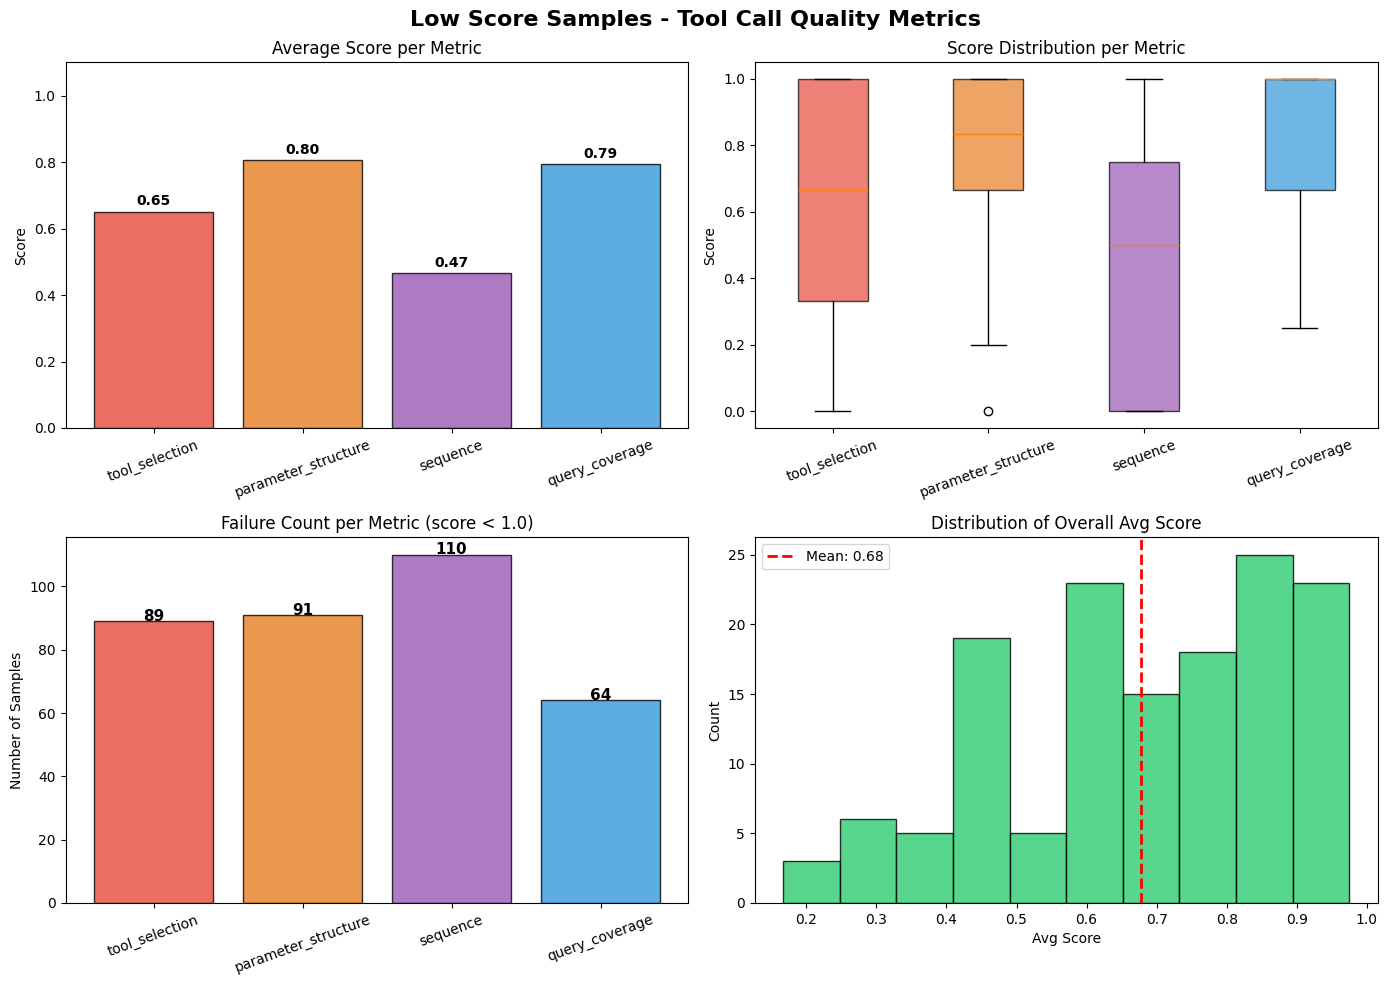

In [306]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Low Score Samples - Tool Call Quality Metrics', fontsize=16, fontweight='bold')

metrics = ['tool_selection', 'parameter_structure', 'sequence', 'query_coverage']
colors = ['#e74c3c', '#e67e22', '#9b59b6', '#3498db']

# --- 1. Average score per metric (Bar chart) ---
ax1 = axes[0, 0]
avg_scores = [low_scores_df[m].mean() for m in metrics]
bars = ax1.bar(metrics, avg_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Average Score per Metric')
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Score')
ax1.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, avg_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# --- 2. Score distribution per metric (Box plot) ---
ax2 = axes[0, 1]
data = [low_scores_df[m].dropna().values for m in metrics]
bp = ax2.boxplot(data, labels=metrics, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title('Score Distribution per Metric')
ax2.set_ylabel('Score')
ax2.tick_params(axis='x', rotation=20)

# --- 3. Failure count per metric (how many samples scored < 1.0) ---
ax3 = axes[1, 0]
failure_counts = [(low_scores_df[m] < 1.0).sum() for m in metrics]
bars3 = ax3.bar(metrics, failure_counts, color=colors, alpha=0.8, edgecolor='black')
ax3.set_title('Failure Count per Metric (score < 1.0)')
ax3.set_ylabel('Number of Samples')
ax3.tick_params(axis='x', rotation=20)
for bar, val in zip(bars3, failure_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', fontsize=11, fontweight='bold')

# --- 4. Overall avg_score histogram ---
ax4 = axes[1, 1]
ax4.hist(low_scores_df['avg_score'], bins=10, color='#2ecc71', edgecolor='black', alpha=0.8)
ax4.axvline(low_scores_df['avg_score'].mean(), color='red', linestyle='--',
            linewidth=2, label=f"Mean: {low_scores_df['avg_score'].mean():.2f}")
ax4.set_title('Distribution of Overall Avg Score')
ax4.set_xlabel('Avg Score')
ax4.set_ylabel('Count')
ax4.legend()

plt.tight_layout()
plt.show()